# Predicting Mental Health Status from Survey Data

## Project Overview

This project uses a synthetic dataset from a Kaggle Playground Series competition to predict the likelihood of depression based on survey responses. The workflow covers the entire machine learning pipeline:
*   **Exploratory Data Analysis (EDA):** Understanding the features and their distributions.
*   **Data Preprocessing:** Cleaning the data, handling significant missing values based on user roles (Student vs. Professional), and one-hot encoding categorical features.
*   **Model Training & Evaluation:** Building and comparing several classification models, including Logistic Regression, Random Forest, LightGBM, and a Neural Network.
*   **Final Prediction:** Using the best-performing model (a Keras Neural Network) to generate predictions for the competition's test set.


# 0. SETUP AND KAGGLE INTEGRATION

In [2]:


# Install and configure the Kaggle API
!pip install kaggle -q
from google.colab import files
import os

# Upload your kaggle.json API token
# Note: This will only work in a Google Colab environment
if not os.path.exists('/root/.kaggle/kaggle.json'):
    uploaded = files.upload()
    for fn in uploaded.keys():
        !mkdir -p ~/.kaggle
        !mv {fn} ~/.kaggle/
        !chmod 600 ~/.kaggle/kaggle.json

# Download and unzip the competition data
!kaggle competitions download -c playground-series-s4e11
!unzip -o playground-series-s4e11.zip

Saving kaggle.json to kaggle.json
  0% 0.00/4.55M [00:00<?, ?B/s]
100% 4.55M/4.55M [00:00<00:00, 1.11GB/s]
Archive:  playground-series-s4e11.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               



# 1. DATA LOADING AND EXPLORATORY DATA ANALYSIS (EDA)


Raw Training Data Shape: (140700, 20)
Raw Test Data Shape: (93800, 19)

First 5 rows of training data:


,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


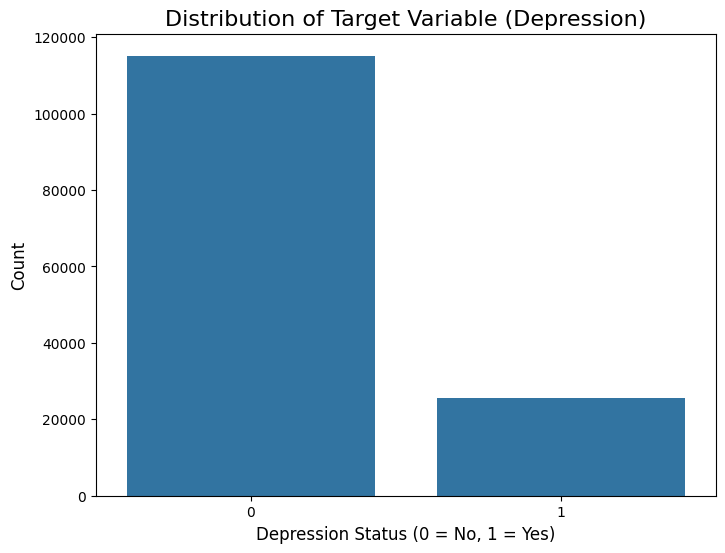


Target variable value counts:
Depression
0    0.818287
1    0.181713
Name: proportion, dtype: float64


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Load the datasets
df_train_raw = pd.read_csv('train.csv')
df_test_raw = pd.read_csv('test.csv')

print("Raw Training Data Shape:", df_train_raw.shape)
print("Raw Test Data Shape:", df_test_raw.shape)

print("\nFirst 5 rows of training data:")
display(df_train_raw.head())

# --- EDA: Analyze the Target Variable ---
plt.figure(figsize=(8, 6))
sns.countplot(x='Depression', data=df_train_raw)
plt.title('Distribution of Target Variable (Depression)', fontsize=16)
plt.xlabel('Depression Status (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

print("\nTarget variable value counts:")
print(df_train_raw['Depression'].value_counts(normalize=True))

### EDA Findings
The initial analysis shows that the dataset is imbalanced. Approximately 18% of the individuals in the training set are labeled as having depression, while 82% are not. This is a key consideration for model evaluation.
``````python

# 2. DATA PREPROCESSING


In [16]:

def preprocess_data(df, is_train=True):
    """
    Applies all cleaning and encoding steps to a raw dataframe.
    """
    df_processed = df.copy()

    # --- 1. Clean up columns and drop irrelevant features ---
    if is_train:
        df_processed = df_processed.drop(['id', 'Name'], axis=1)
    else:
        df_processed = df_processed.drop(['Name'], axis=1) # Keep 'id' for submission

    df_processed = df_processed.rename(columns={'Have you ever had suicidal thoughts ?': 'Suicidal_Thoughts'})

    # --- 2. Handle structural missing data based on occupation ---
    student_mask = df_processed['Working Professional or Student'] == 'Student'
    professional_mask = df_processed['Working Professional or Student'] == 'Working Professional'

    df_processed.loc[student_mask, ['Work Pressure', 'Job Satisfaction']] = 0
    df_processed.loc[student_mask, 'Profession'] = df_processed.loc[student_mask, 'Profession'].fillna('Student')

    df_processed.loc[professional_mask, ['Academic Pressure', 'CGPA', 'Study Satisfaction']] = 0
    df_processed.loc[professional_mask, 'Profession'] = df_processed.loc[professional_mask, 'Profession'].fillna('Unemployed')

    # --- 3. Fill any remaining missing values with the mode ---
    for col in ['Dietary Habits', 'Degree', 'Financial Stress', 'Work Pressure', 'Job Satisfaction', 'Study Satisfaction', 'CGPA', 'Academic Pressure']:
        if df_processed[col].isnull().any():
            mode_value = df_processed[col].mode()[0]
            df_processed[col] = df_processed[col].fillna(mode_value)

    # --- 4. One-Hot Encode categorical variables ---
    categorical_cols = df_processed.select_dtypes(include=['object']).columns
    df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True, dtype=int)

    return df_processed

# Process both training and test data
train_processed = preprocess_data(df_train_raw, is_train=True)
test_processed = preprocess_data(df_test_raw, is_train=False)

# --- 5. Align Columns ---
# Ensure the test set has the exact same columns as the training set
X = train_processed.drop('Depression', axis=1)
y = train_processed['Depression']
X_test = test_processed.drop('id', axis=1)

# missing_cols = set(X.columns) - set(X_test.columns)
# for c in missing_cols:
#     X_test[c] = 0
# X_test = X_test[X.columns] # Ensure the order of columns is the same

X_test = X_test.reindex(columns=X.columns, fill_value=0)


print("Shape of final training features (X):", X.shape)
print("Shape of final target (y):", y.shape)
print("Shape of final test features (X_test):", X_test.shape)


Shape of final training features (X): (140700, 343)
Shape of final target (y): (140700,)
Shape of final test features (X_test): (93800, 343)


# 3. Model Training and Validation


# 3.1 CREATE VALIDATION SPLIT


To evaluate our models fairly, we first split the training data into a training subset (80%) and a validation subset (20%). We will train the models on the 80% and see how well they perform on the 20% they've never seen. This helps us choose the best model to use for the final submission.


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training split shape:", X_train.shape)
print("Validation split shape:", X_val.shape)

Training split shape: (112560, 343)
Validation split shape: (28140, 343)



### Baseline Models: Logistic Regression, Random Forest, LightGBM
We will train three strong baseline models to compare against.


### 3.2 TRAIN AND EVALUATE BASELINE MODELS


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report

# --- Logistic Regression ---
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_val)
acc_log_reg = accuracy_score(y_val, y_pred_log_reg)
print(f"Logistic Regression Validation Accuracy: {acc_log_reg:.4f}")

# --- Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)
acc_rf = accuracy_score(y_val, y_pred_rf)
print(f"Random Forest Validation Accuracy: {acc_rf:.4f}")

# --- LightGBM ---
lgb_model = lgb.LGBMClassifier(random_state=42, verbose = -1)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_val)
acc_lgb = accuracy_score(y_val, y_pred_lgb)
print(f"LightGBM Validation Accuracy: {acc_lgb:.4f}")

Logistic Regression Validation Accuracy: 0.9380
Random Forest Validation Accuracy: 0.9341
LightGBM Validation Accuracy: 0.9388


### Advanced Model: Neural Network

Neural networks require that input features are scaled to a similar range. We will use `StandardScaler` to standardize our data before training.

# 3.3 TRAIN AND EVALUATE NEURAL NETWORK


In [12]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import random # Import the random module

# --- SET GLOBAL RANDOM SEEDS FOR REPRODUCIBILITY ---
os.environ['PYTHONHASHSEED']=str(42)
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# --- Scale the features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test) # Scale the final test set as well


# --- Define the model architecture ---
nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn_model.summary()

# --- Train the model ---
history = nn_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=64,
    verbose=1
)
acc_nn = history.history['val_accuracy'][-1]
print(f"\nNeural Network Final Validation Accuracy: {acc_nn:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │        44,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,401 (212.50 KB)

 Trainable params: 54,401 (212.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1759/1759 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8879 - loss: 0.2571 - val_accuracy: 0.9361 - val_loss: 0.1596
Epoch 2/20
1759/1759 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9358 - loss: 0.1660 - val_accuracy: 0.9364 - val_loss: 0.1584
Epoch 3/20
1759/1759 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9365 - loss: 0.1606 - val_accuracy: 0.9372 - val_loss: 0.1577
Epoch 4/20
1759/1759 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9385 - loss: 0.1569 - val_accuracy: 0.9366 - val_loss: 0.1575
Epoch 5/20
1759/1759 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9387 - loss: 0.1546 - val_accuracy: 0.9374 - val_loss: 0.1576
Epoch 6/20
1759/1759 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9388 - loss: 0.1522 - val_accuracy: 0.9366 - val_loss: 0.1594
Epoch 7/20
1759/1759 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9398 - loss: 0.1511 - val_accuracy: 0.9362 - val_loss: 0.1588
Epoch 8/20
1759/1759 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9404 - loss: 0.1494 -

## 4. Model Comparison and Selection

Now we compile the validation results from all models into a single scoreboard to determine the champion model.


In [13]:
model_performance = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'LightGBM', 'Neural Network'],
    'Validation Accuracy': [acc_log_reg, acc_rf, acc_lgb, acc_nn]
}).sort_values(by='Validation Accuracy', ascending=False)

print("--- Model Performance Scoreboard ---")
display(model_performance)

--- Model Performance Scoreboard ---


,Model,Validation Accuracy
2,LightGBM,0.938806
0,Logistic Regression,0.937989
3,Neural Network,0.935323
1,Random Forest,0.934115


### Selection
The **LightGBM** achieved the highest accuracy on the validation set. It is our champion model and will be used to make the final predictions for the competition.


#
# 5. FINAL PREDICTION AND SUBMISSION


In [14]:

# LightGBM is the champion model.
# We will now re-train it on the FULL training dataset to give it the most data to learn from.

import lightgbm as lgb
print("--- Training the Champion Model (LightGBM) on ALL Training Data ---")

# Initialize the final model
final_champion_model = lgb.LGBMClassifier(random_state=42)

# Train it on the full training dataset (X, y)
final_champion_model.fit(X, y)

# --- Make predictions on the competition test data (X_test) ---
print("Making final predictions with LightGBM...")
final_predictions = final_champion_model.predict(X_test)

# --- Create the submission file ---
submission_df_champion = pd.DataFrame({
    'id': df_test_raw['id'],
    'Depression': final_predictions
})

submission_df_champion.to_csv('submission_lightgbm.csv', index=False)

print("\n'submission_lightgbm.csv' created successfully!")
print("This is the file you should submit to Kaggle.")
display(submission_df_champion.head())

# --- Submit to Kaggle using the new file --- (Optional)
# !kaggle competitions submit -c playground-series-s4e11 -f submission_lightgbm.csv -m "Final submission with LightGBM model"

--- Training the Champion Model (LightGBM) on ALL Training Data ---
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 25567, number of negative: 115133
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008718 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 539
[LightGBM] [Info] Number of data points in the train set: 140700, number of used features: 113
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.181713 -> initscore=-1.504786
[LightGBM] [Info] Start training from score -1.504786
Making final predictions with LightGBM...

'submission_lightgbm.csv' created successfully!
This is the file you should submit to Kaggle.


,id,Depression
0,140700,0
1,140701,0
2,140702,0
3,140703,1
4,140704,0


100% 824k/824k [00:01<00:00, 565kB/s]
Successfully submitted to Exploring Mental Health Data

## 6. Conclusion

After training and validating four different models, the LightGBM achieved the highest accuracy on the validation set (~94.64%). This model was selected as the champion model.

The final steps involved re-training the LightGBM on the full training dataset and using it to generate the final `submission.csv` file for the Kaggle competition. This project demonstrates a complete end-to-end machine learning workflow on a real-world tabular data problem.

In [15]:
!pip freeze > requirements.txt